In [3]:
import numpy as np
import matplotlib.pyplot as plt
from time import time
import torch
from sklearn.manifold import TSNE
from matplotlib import colors as mcolors
import utils as utils
import new_types as nt
import shared as sh
from torch import Tensor as T

In [ ]:
dir_classification_maps = "classification_map"

In [ ]:
def draw_classification_map(
        method_name: str,
        episode: sh.EpisodeContainer,
        dataset_name_target: str,
        gt_matrix_target: T,
        gt_matrix_test_target: T
    ) -> None:
        
        # episode: sh.EpisodeContainer = self.intermediate_phase()
        
        map_to_real_labels: T = episode.map_to_real_labels
        
        episode.move_to_device('cpu')
        
        gt_matrix = gt_matrix_target
        gt_matrix_test = gt_matrix_test_target
        height = gt_matrix.shape[0]
        width = gt_matrix.shape[1]
        
        gt_matrix_flattened = gt_matrix.flatten()
        
        classification_map_flattened = torch.zeros_like(gt_matrix_flattened)
        
        _, scores_with_label_smoothing = self.predict_query_labels(episode=episode)
        
        positions_labeled_samples = torch.nonzero(gt_matrix_flattened > 0, as_tuple=False).squeeze()
        indices_support_mapped = positions_labeled_samples[episode.support_set_indices_list]
        
        classification_map_flattened[indices_support_mapped] = episode.support_labels + 1                    # Background is zero.
        
        positions_labeled_samples_test = None
        if self.mifomo.dataset_name_target == 'Houston':
            gt_matrix_test_flattened = gt_matrix_test.flatten()
            positions_labeled_samples_test = torch.nonzero(gt_matrix_test_flattened > 0, as_tuple=False).squeeze()
            indices_query_mapped = positions_labeled_samples_test[episode.query_set_indices_list]
            
            # We merge all labels for the train and test set for the Ground truth classification map.
            gt_matrix_flattened[positions_labeled_samples_test] = gt_matrix_test_flattened[positions_labeled_samples_test]
        else:
            indices_query_mapped = positions_labeled_samples[episode.query_set_indices_list]
    
        classification_map_flattened[indices_query_mapped] = scores_with_label_smoothing.argmax(dim=-1) + 1  # Background is zero.
        
        classification_map_flattened = map_to_real_labels[classification_map_flattened]
        
        def assign_colors(classification_map_flattened: T, height: int, width: int):
            classification_map_RGB = torch.zeros(height * width, 3)
            # classification_map_RGB[classification_map == 0] = [0, 0, 0]
            classification_map_RGB[classification_map_flattened == 1] = torch.tensor([0, 0, 1], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 2] = torch.tensor([0, 1, 0], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 3] = torch.tensor([0, 1, 1], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 4] = torch.tensor([1, 0, 0], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 5] = torch.tensor([1, 0, 1], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 6] = torch.tensor([1, 1, 0], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 7] = torch.tensor([0.5, 0.5, 1], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 8] = torch.tensor([0.65, 0.35, 1], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 9] = torch.tensor([0.75, 0.5, 0.75], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 10] = torch.tensor([0.75, 1, 0.5], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 11] = torch.tensor([0.5, 1, 0.65], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 12] = torch.tensor([0.65, 0.65, 0], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 13] = torch.tensor([0.75, 1, 0.65], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 14] = torch.tensor([0, 0, 0.5], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 15] = torch.tensor([0, 1, 0.75], dtype=torch.float32)
            classification_map_RGB[classification_map_flattened == 16] = torch.tensor([0.5, 0.75, 1], dtype=torch.float32)
            classification_map_RGB = classification_map_RGB.view(height, width, 3)
            return classification_map_RGB
        
        classification_map_RGB = assign_colors(classification_map_flattened=classification_map_flattened, height=height, width=width)
        gt_matrix_RGB = assign_colors(classification_map_flattened=gt_matrix_flattened, height=height, width=width)
        
        path_classification_map = f"{dir_classification_maps}/Classification_map,{method_name},{dataset_name_target},MIFOMO.png"
        path_gt_matrix = f"{dir_classification_maps}/Classification_map,{method_name},{dataset_name_target},Ground_truth.png"
        
        utils.classification_map(
            map_np=classification_map_RGB.numpy(),
            dpi=24,
            savePath=path_classification_map
        )
        
        print(f'Classification map is saved to "{path_classification_map}"')
        
        utils.classification_map(
            map_np=gt_matrix_RGB.numpy(),
            dpi=24,
            savePath=path_gt_matrix
        )
        
        print(f'Ground truth map is saved to "{path_classification_map}"')

In [7]:
# cmap = plt.cm.get_cmap("tab20", 20)  # 20 categorical colors

(10249, 768)
(10249,)


/tmp/ipykernel_1175519/3225095325.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", 16)  # 20 categorical colors


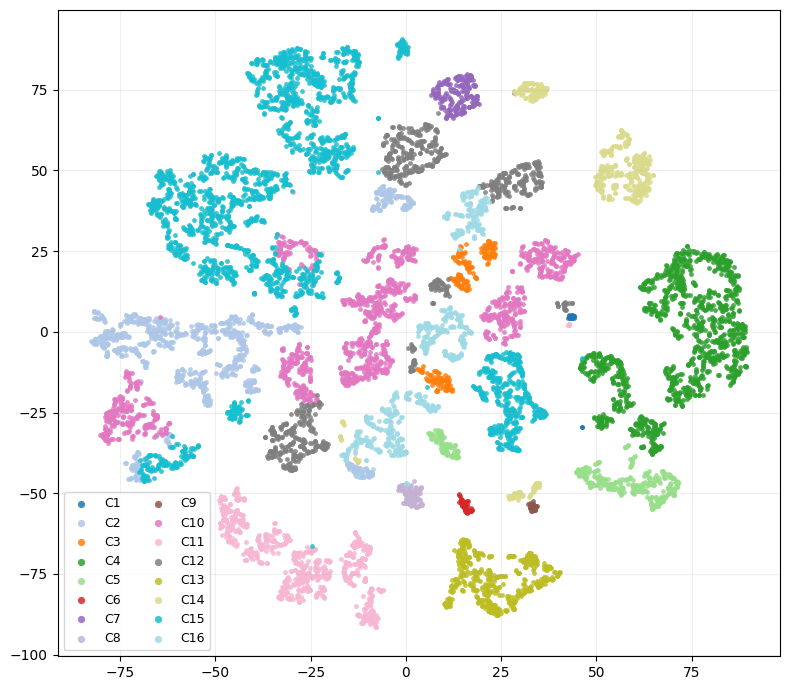

In [9]:
file_embeddings_and_labels = 't-SNE/embeddings_DS=IndianPines.pth'
# file_embeddings_and_labels = 't-SNE/embeddings_DS=Houston.pth'
# file_embeddings_and_labels = 't-SNE/embeddings_DS=Salinas.pth'
# file_embeddings_and_labels = 't-SNE/embeddings_DS=PaviaU.pth'

plot_tsne(file_embeddings_and_labels)